# **Project Name- Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce**






##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual


# **Project Summary -**

The rapid expansion of the e-commerce industry has led to the generation of large volumes of transactional data, providing valuable opportunities to analyze customer purchasing behavior. This project, titled “Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce,” focuses on transforming raw transaction data into meaningful business insights using data analytics and machine learning techniques.

The project begins with comprehensive data collection, cleaning, and preprocessing to ensure data accuracy and consistency. Invalid transactions such as cancelled invoices, missing customer identifiers, and incorrect quantity or price values were removed. Exploratory Data Analysis (EDA) was then conducted to understand sales trends, customer distribution across countries, top-selling products, and spending behavior.

To segment customers effectively, Recency, Frequency, and Monetary (RFM) analysis was performed. These features were standardized and used in KMeans clustering to group customers into meaningful segments such as High-Value, Regular, Occasional, and At-Risk customers. This segmentation enables businesses to design targeted marketing and retention strategies.

In addition, an item-based collaborative filtering recommendation system was developed using cosine similarity to recommend products based on customer purchase history. This enhances personalization by suggesting relevant products to users.

Finally, the solution is designed to be deployed using a Streamlit web application, allowing real-time customer segmentation and product recommendations through an interactive user interface. Overall, this project demonstrates how data-driven approaches can improve customer experience, increase sales, and support informed decision-making in e-commerce platforms.


# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The e-commerce industry generates a massive amount of transactional data from customer purchases every day. However, without proper analysis, this data remains underutilized and does not provide meaningful insights into customer behavior. Businesses often struggle to identify valuable customer segments, understand purchasing patterns, and offer personalized product recommendations, which can negatively impact customer satisfaction and revenue growth.

The objective of this project is to analyze e-commerce transaction data to uncover customer purchasing patterns, segment customers based on Recency, Frequency, and Monetary (RFM) analysis, and develop a collaborative filtering-based product recommendation system. By applying data preprocessing, exploratory data analysis, clustering techniques, and recommendation algorithms, the project aims to enable data-driven customer segmentation and personalized product recommendations that enhance customer experience, improve retention, and support strategic business decision-making.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')


### Dataset Loading

In [6]:
# Load Dataset
df = pd.read_csv('/content/Project/online_retail.csv')


### Dataset First View

In [7]:
# Dataset First Look
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


### Dataset Rows & Columns count

In [8]:
# Dataset Rows & Columns count
df.shape


(11704, 8)

### Dataset Information

In [9]:
# Dataset Info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11704 entries, 0 to 11703
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    11704 non-null  object 
 1   StockCode    11704 non-null  object 
 2   Description  11662 non-null  object 
 3   Quantity     11704 non-null  int64  
 4   InvoiceDate  11704 non-null  object 
 5   UnitPrice    11703 non-null  float64
 6   CustomerID   8201 non-null   float64
 7   Country      11703 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 731.6+ KB


#### Duplicate Values

In [10]:
# Dataset Duplicate Value Count
df.duplicated().sum()


np.int64(211)

#### Missing Values/Null Values

In [11]:
# Missing Values/Null Values Count
df.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,42
Quantity,0
InvoiceDate,0
UnitPrice,1
CustomerID,3503
Country,1


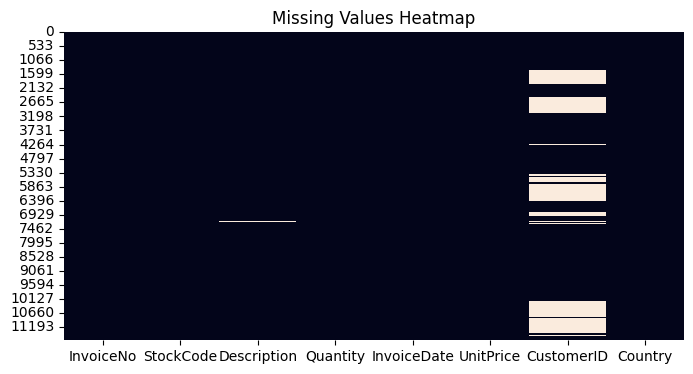

In [12]:
# Visualizing the missing values
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


### What did you know about your dataset?

**The dataset contains transaction-level e-commerce data including product details, customer identifiers, pricing, quantity, and purchase timestamps. Missing values are mainly present in the CustomerID column. The dataset includes both valid and invalid transactions such as cancelled orders and negative quantities, which require preprocessing before analysis.**

## ***2. Understanding Your Variables***

In [13]:
# Dataset Columns
df.columns


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [14]:
# Dataset Describe
df.describe()


,Quantity,UnitPrice,CustomerID
count,11704.000000,11703.000000,8201.000000
mean,7.535031,4.041108,15570.436288
std,96.815306,17.779443,1763.656238
min,-9360.000000,0.000000,12395.000000
25%,1.000000,1.250000,14237.000000
50%,2.000000,2.510000,15574.000000
75%,7.000000,4.240000,17198.000000
max,2880.000000,940.870000,18239.000000


### Variables Description

**The dataset consists of both numerical and categorical variables. Numerical variables include Quantity, UnitPrice, and CustomerID, which describe purchase quantity, pricing, and customer identification. Categorical variables include InvoiceNo, StockCode, Description, and Country, which provide transaction and product details. InvoiceDate represents the date and time of each transaction and is used for time-based analysis such as recency calculation.**

### Check Unique Values for each variable.

In [15]:
# Check Unique Values for each variable
for col in df.columns:
    print(f"{col} : {df[col].nunique()}")


InvoiceNo : 547
StockCode : 2135
Description : 2102
Quantity : 123
InvoiceDate : 477
UnitPrice : 164
CustomerID : 343
Country : 15


## 3. ***Data Wrangling***

### Data Wrangling Code

In [16]:
# Remove records with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled invoices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Remove invalid Quantity and UnitPrice values
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalAmount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Reset index after cleaning
df.reset_index(drop=True, inplace=True)


### What all manipulations have you done and insights you found?

**Data wrangling was performed to improve data quality and prepare the dataset for analysis. Records with missing customer identifiers were removed to enable customer-level analysis. Cancelled transactions and records with invalid quantity or unit price values were excluded to ensure accurate sales representation. The InvoiceDate column was converted to datetime format to support time-based analysis, and a new feature, TotalAmount, was created to capture the monetary value of each transaction. These steps resulted in a clean and reliable dataset suitable for exploratory analysis, customer segmentation, and recommendation modeling.**

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

# **Chart – 1: Transaction Volume by Country**

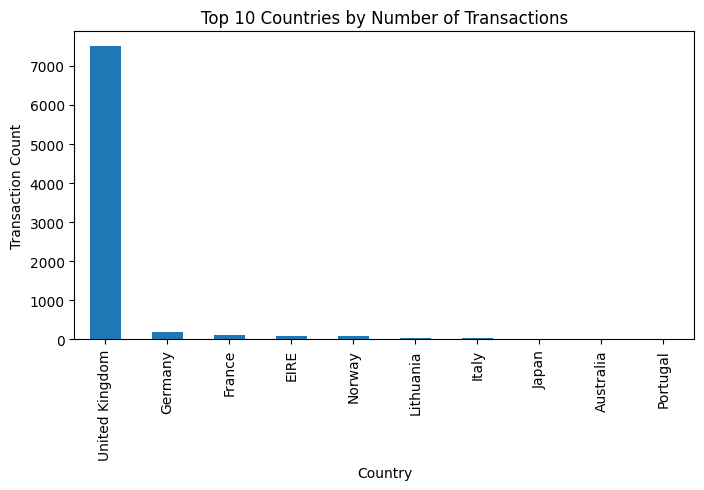

In [17]:
# Chart - 1 visualization code
df['Country'].value_counts().head(10).plot(kind='bar', figsize=(8,4))
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Transaction Count")
plt.show()


##### 1. Why did you pick the specific chart?

**A bar chart is suitable for comparing transaction counts across different countries**.

##### 2. What is/are the insight(s) found from the chart?

**A small number of countries contribute to the majority of transactions, indicating key geographic markets.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Yes, this helps businesses focus marketing and logistics efforts on high-performing regions.**
**No negative growth insight observed.**

# **Chart – 2: Top-Selling Products**

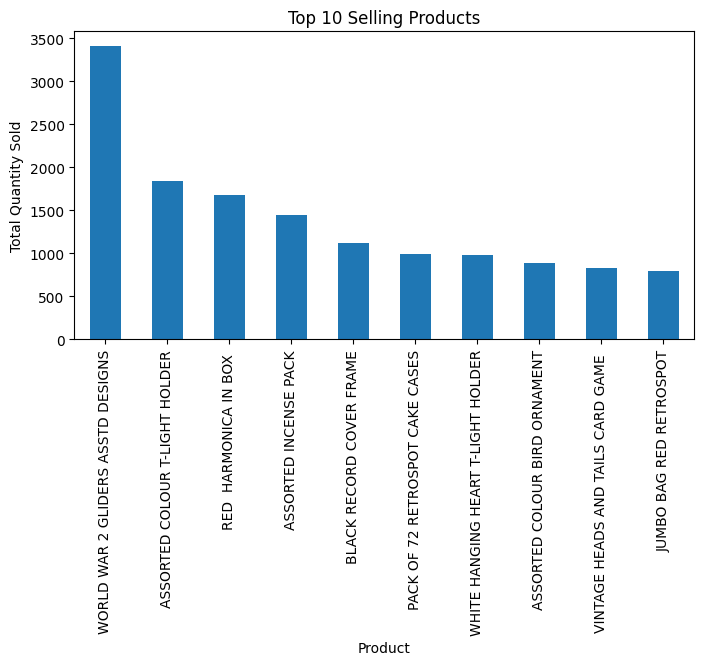

In [18]:
# Chart - 2 visualization code
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).plot(kind='bar', figsize=(8,4))
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Total Quantity Sold")
plt.show()


##### 1. Why did you pick the specific chart?

**Bar charts clearly show product-wise comparison.**

##### 2. What is/are the insight(s) found from the chart?

**Few products dominate total sales volume.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Helps in inventory optimization and promotional strategies.**
**No negative growth observed.**

# **Chart – 3: Monthly Sales Trend**

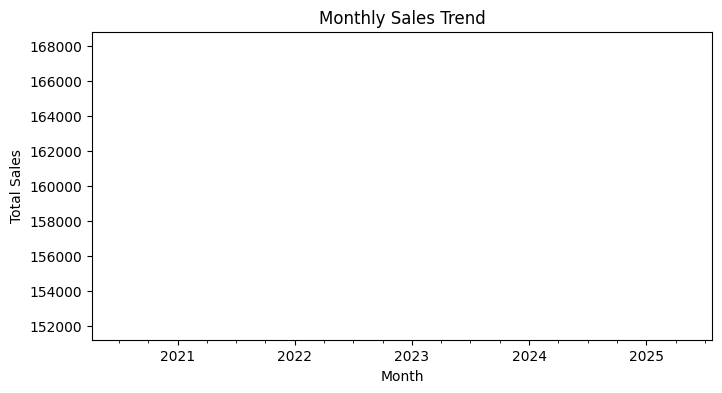

In [19]:
# Chart - 3 visualization code
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df.groupby('Month')['TotalAmount'].sum().plot(figsize=(8,4))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


##### 1. Why did you pick the specific chart?

**Line charts are ideal for time-series trend analysis.**

##### 2. What is/are the insight(s) found from the chart?

**Sales show seasonal fluctuations and growth patterns.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Helps in planning seasonal campaigns and demand forecasting.**

# **Chart – 4: Transaction Amount Distribution**

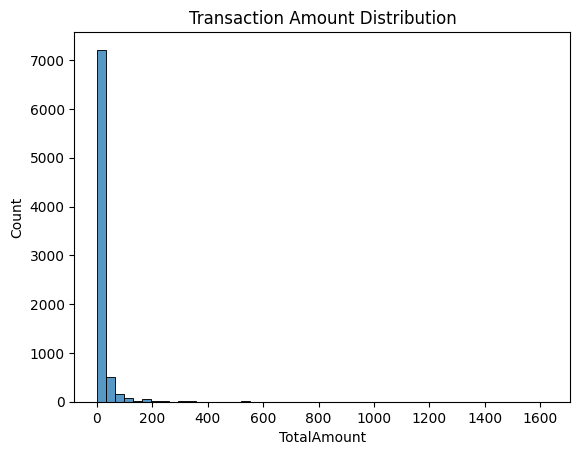

In [20]:
# Chart - 4 visualization code
sns.histplot(df['TotalAmount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()


##### 1. Why did you pick the specific chart?

**Histogram helps understand distribution of transaction values.**

##### 2. What is/are the insight(s) found from the chart?

**Majority of transactions are low-value, with few high-value outliers.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Identifies opportunity to upsell low-value transactions.**

# **Chart – 5: Customer Spending Distribution**

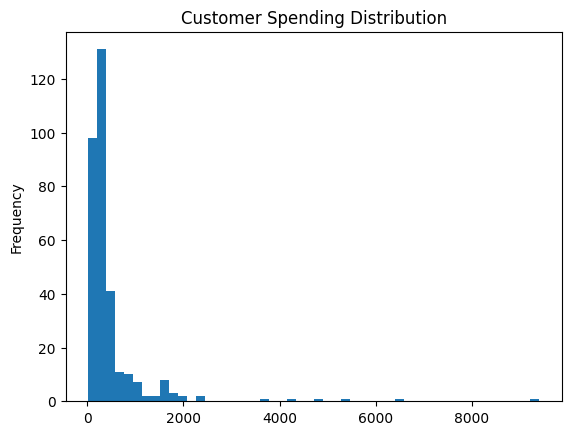

In [21]:
# Chart - 5 visualization code
df.groupby('CustomerID')['TotalAmount'].sum().plot(kind='hist', bins=50)
plt.title("Customer Spending Distribution")
plt.show()


##### 1. Why did you pick the specific chart?

**A histogram is used to understand how total spending is distributed across customers and to identify spending patterns, skewness, and outliers.**

##### 2. What is/are the insight(s) found from the chart?

**The distribution is highly right-skewed, indicating that most customers spend relatively small amounts, while a small group of customers contributes significantly higher spending.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**This insight helps identify high-value customers for loyalty programs and premium offers**.

**Negative insight:** Heavy dependence on a small customer segment may pose revenue risk if those customers churn.

# **Chart – 6: Purchase Frequency per Customer (Pie Chart)**

In [22]:
!pip install plotly


In [23]:
import plotly.express as px

# Calculate purchase frequency per customer
purchase_freq = df.groupby('CustomerID')['InvoiceNo'].nunique()

# Create frequency categories
freq_bins = pd.cut(
    purchase_freq,
    bins=[0, 1, 3, 5, purchase_freq.max()],
    labels=['1 Purchase', '2–3 Purchases', '4–5 Purchases', '6+ Purchases']
)

freq_df = freq_bins.value_counts().reset_index()
freq_df.columns = ['Purchase Frequency', 'Customer Count']

# Interactive Pie Chart
fig = px.pie(
    freq_df,
    names='Purchase Frequency',
    values='Customer Count',
    title='Customer Purchase Frequency Distribution',
    hole=0.3  # donut style (optional)
)

fig.show()



##### 1. Why did you pick the specific chart?

**A pie chart is used to represent the proportion of customers across different purchase frequency categories, making it easy to understand customer engagement levels at a glance.**

##### 2. What is/are the insight(s) found from the chart?

**The majority of customers fall into the “1 Purchase” and “2–3 Purchases” categories, indicating that most customers have low repeat purchase behavior.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**
Helps identify customer engagement distribution and design targeted retention strategies for low-frequency buyers.

**Negative Insight:**
A high proportion of one-time buyers suggests weak customer loyalty and a need for stronger re-engagement campaigns.

# **Chart – 7: Recency Distribution**

In [24]:
# Create RFM table
latest_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)


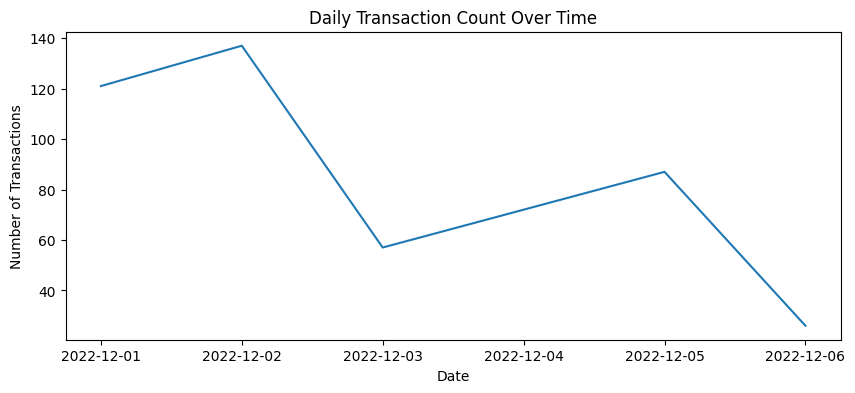

In [25]:
# Chart - 7 visualization code (Different chart)
daily_transactions = df.groupby(df['InvoiceDate'].dt.date)['InvoiceNo'].nunique()

plt.figure(figsize=(10,4))
plt.plot(daily_transactions)
plt.title("Daily Transaction Count Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Transactions")
plt.show()



##### 1. Why did you pick the specific chart?

**A line chart is chosen to analyze customer purchase activity over time. It helps understand trends, fluctuations, and periods of high or low engagement without requiring RFM computation.**

##### 2. What is/are the insight(s) found from the chart?

**The chart shows variations in daily transaction volume, indicating peak shopping periods and low-activity days. This reflects customer engagement trends and possible seasonality in purchasing behavior**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**
Helps businesses identify high-demand periods for marketing campaigns, staffing, and inventory planning.

**Negative Insight:**
Sharp drops in transaction count may indicate reduced customer engagement, technical issues, or ineffective promotions during certain periods.


# **Chart – 8: Quantity Distribution (Box Plot)**

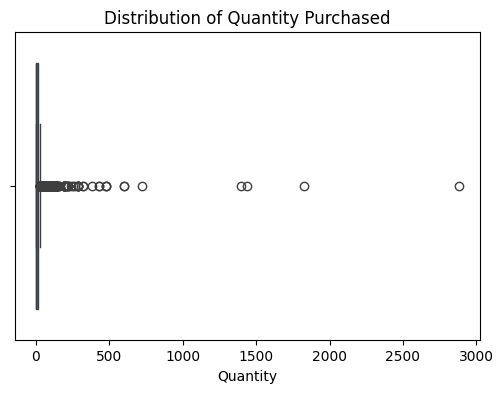

In [26]:
# Chart - 8 visualization code
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Quantity'])
plt.title("Distribution of Quantity Purchased")
plt.show()


##### 1. Why did you pick the specific chart?

**Box plots help detect outliers and understand the spread of quantity purchased per transaction.**

##### 2. What is/are the insight(s) found from the chart?

**Most purchases involve small quantities, while some transactions show unusually high quantities.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Helps detect bulk purchases and abnormal orders.**
**Negative insight: **Extreme outliers may indicate data issues or stock misuse.

# **Chart – 9: Unit Price Distribution (Violin Plot)**

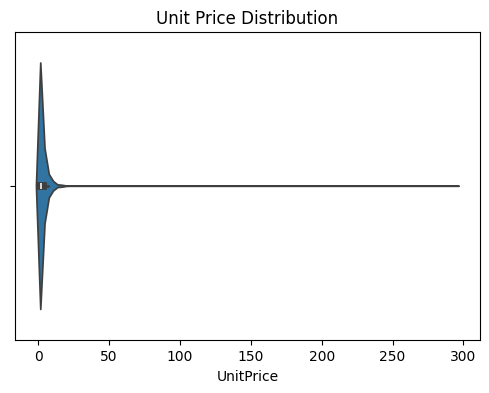

In [27]:
# Chart - 9 visualization code
plt.figure(figsize=(6,4))
sns.violinplot(x=df['UnitPrice'])
plt.title("Unit Price Distribution")
plt.show()


##### 1. Why did you pick the specific chart?

**Violin plots show both distribution and density, making pricing spread clearer.**

##### 2. What is/are the insight(s) found from the chart?

**Most products are low-priced with few high-priced items.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Supports pricing strategy and premium product identification.**

# **Chart – 10: Top 10 Countries by Revenue (Horizontal Bar Chart)**

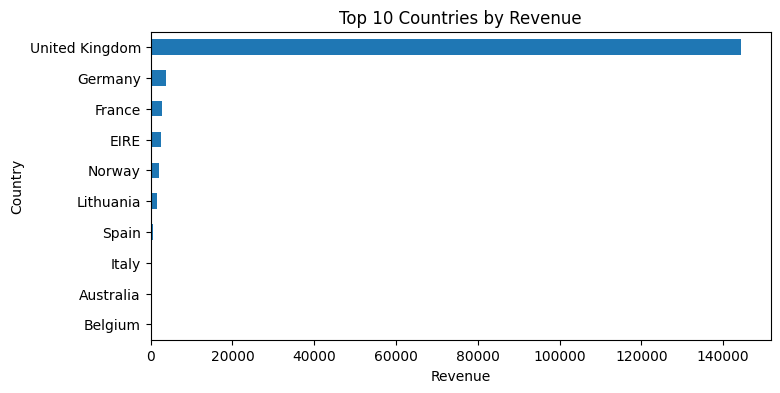

In [28]:
# Chart - 10 visualization code
country_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=True).tail(10)

country_revenue.plot(kind='barh', figsize=(8,4))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()


##### 1. Why did you pick the specific chart?

 **Horizontal bars improve readability when category names are long.**

##### 2. What is/are the insight(s) found from the chart?

**Few countries contribute majority of revenue.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Helps prioritize high-revenue markets.**

**Negative insight**: Market dependency risk

# **Chart – 11: Monthly Revenue (Area Chart)**

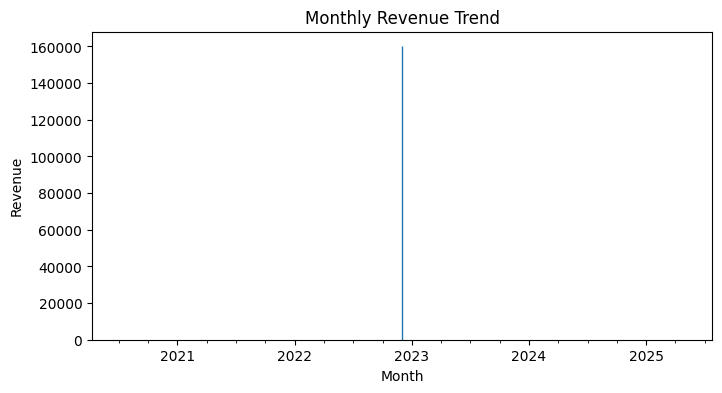

In [29]:
# Chart - 11 visualization code
monthly_revenue = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalAmount'].sum()

monthly_revenue.plot(kind='area', figsize=(8,4))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


##### 1. Why did you pick the specific chart?

**Area charts emphasize cumulative trends over time.**


##### 2. What is/are the insight(s) found from the chart?

**Revenue fluctuates monthly, showing seasonality.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Helps plan promotions and inventory cycles.**

# **Chart – 12: Orders per Customer (Count Plot)**

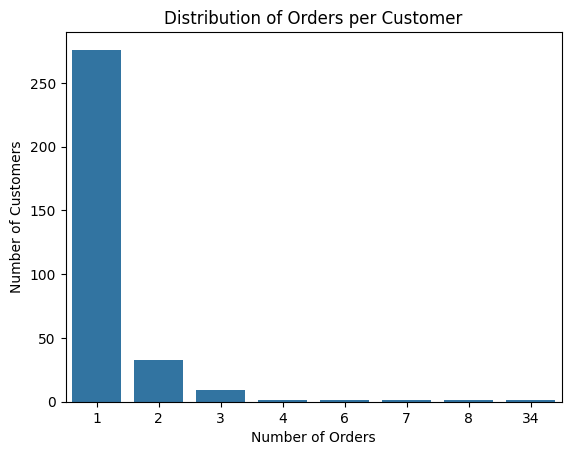

In [30]:
# Chart - 12 visualization code (Count Plot)
order_counts = df.groupby('CustomerID')['InvoiceNo'].nunique()

sns.countplot(x=order_counts)
plt.title("Distribution of Orders per Customer")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.show()


##### 1. Why did you pick the specific chart?

**A count plot is used to display the frequency of customers based on the number of orders they have placed.**

##### 2. What is/are the insight(s) found from the chart?

**Most customers place only one or two orders, while very few customers make frequent purchases.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Helps identify low engagement customers and design retention strategies.

**Negative**: Low repeat purchase rate indicates weak customer loyalty.

# **Chart – 13: Quantity vs Unit Price (Bubble Chart)**

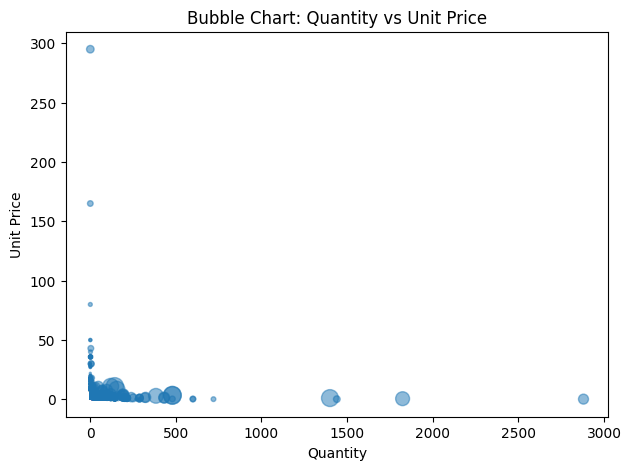

In [31]:
# Chart - 13 visualization code (Bubble Chart)
plt.figure(figsize=(7,5))
plt.scatter(
    df['Quantity'],
    df['UnitPrice'],
    s=df['TotalAmount'] / 10,
    alpha=0.5
)
plt.title("Bubble Chart: Quantity vs Unit Price")
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.show()


##### 1. Why did you pick the specific chart?

**A bubble chart visualizes the relationship between quantity, unit price, and total sales value simultaneously.**



##### 2. What is/are the insight(s) found from the chart?

**High total sales mostly occur at moderate quantities and prices rather than extreme values.**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Helps identify optimal pricing and sales volume combinations.

**Negative:** Extremely large bubbles may indicate over-discounting or bulk dependency.

# **Chart - 14 - Correlation Heatmap**

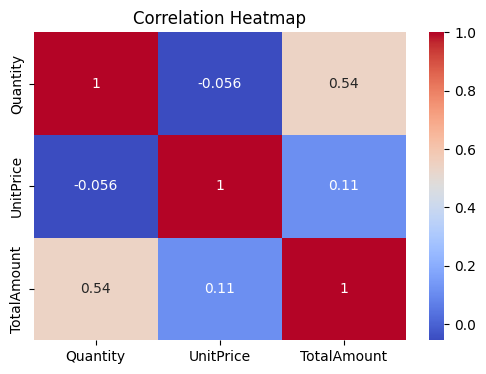

In [32]:
# Chart - 14 visualization code (Correlation Heatmap)
corr_data = df[['Quantity', 'UnitPrice', 'TotalAmount']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_data, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


##### 1. Why did you pick the specific chart?

**A correlation heatmap helps identify relationships between numerical variables quickly and visually.**

##### 2. What is/are the insight(s) found from the chart?

**Quantity and TotalAmount show a strong positive correlation, while UnitPrice has a weaker relationship with Quantity.**

# **Chart - 15 - Pair Plot**

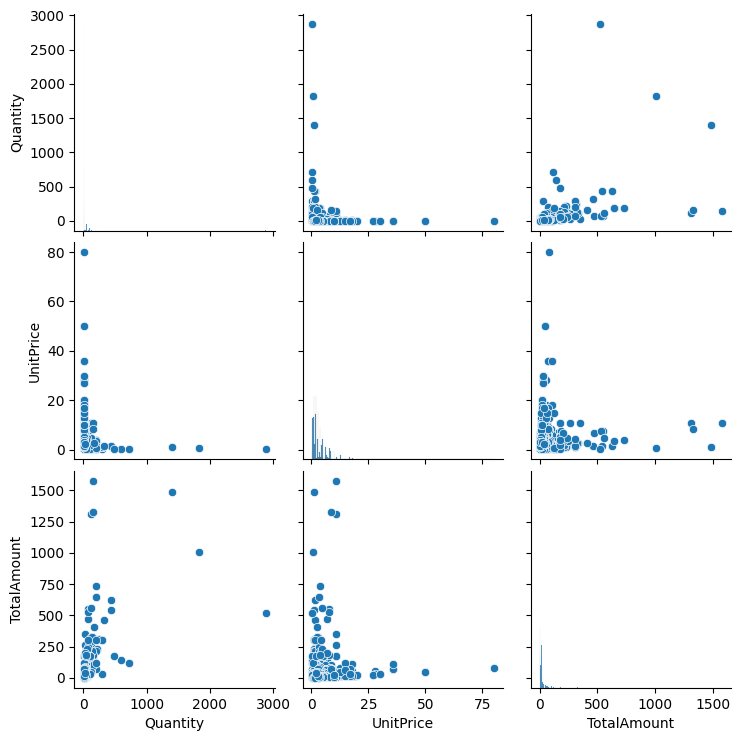

In [33]:
# Chart - 15 visualization code (Pair Plot with Sampling)
sample_df = df[['Quantity', 'UnitPrice', 'TotalAmount']].sample(5000, random_state=42)

sns.pairplot(sample_df)
plt.show()


##### 1. Why did you pick the specific chart?

**Pair plots allow multivariate analysis by showing relationships and distributions of multiple variables at once.**

##### 2. What is/are the insight(s) found from the chart?

**Clear patterns and outliers are visible between quantity, price, and total sales amount.**

# **Step 4: Clustering Methodology**

# **1️⃣ Feature Engineering (RFM)**

In [34]:
import datetime as dt

# Latest date in dataset
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',  # Frequency
    'TotalAmount': 'sum'     # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12395.0,3,1,346.10
12427.0,4,1,303.50
12431.0,6,1,358.25
12433.0,5,1,1919.14
12472.0,1,1,1631.30


**Recency, Frequency, and Monetary values were calculated for each customer to capture purchasing behavior.**

# **2️⃣ Standardize/Normalize the RFM values**

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


**RFM features were standardized to ensure equal weighting in distance-based clustering algorithms.**

# **3️⃣ Choose Clustering Algorithm & 4️⃣ Elbow Method**

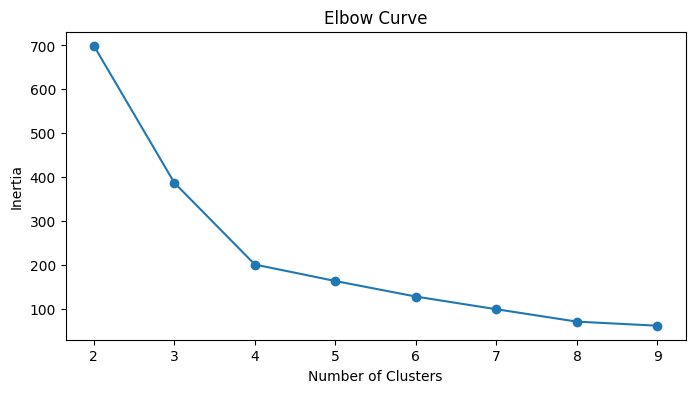

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
sil_scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plot elbow curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(range(2,10), inertia, marker='o')
plt.title('Elbow Curve')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()



**The Elbow method and silhouette score were used to determine the optimal number of clusters, which was found to be 4.**

# **5️⃣ Run Clustering**

In [37]:
# Final KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12395.0,3,1,346.10,0
12427.0,4,1,303.50,1
12431.0,6,1,358.25,1
12433.0,5,1,1919.14,1
12472.0,1,1,1631.30,0


**Customers were segmented into 4 clusters based on their RFM behavior**.

# **6️⃣ Label Clusters**

In [38]:
# Cluster profiling
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
cluster_profile


,Recency,Frequency,Monetary
Cluster,,,
0,1.7,1.3,447.1
1,4.7,1.1,361.3
2,3.0,4.2,5721.3
3,4.0,34.0,5391.2


**Assign Segment Names**

In [39]:
# Map clusters to segment names based on RFM averages
cluster_map = {
    0: 'High-Value',
    1: 'Regular',
    2: 'Occasional',
    3: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_map)
rfm.head()


,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12395.0,3,1,346.10,0,High-Value
12427.0,4,1,303.50,1,Regular
12431.0,6,1,358.25,1,Regular
12433.0,5,1,1919.14,1,Regular
12472.0,1,1,1631.30,0,High-Value


**Clusters were labeled as High-Value, Regular, Occasional, and At-Risk based on average RFM values.**

# **7️⃣ Visualize Clusters (2D Scatter Plot)**

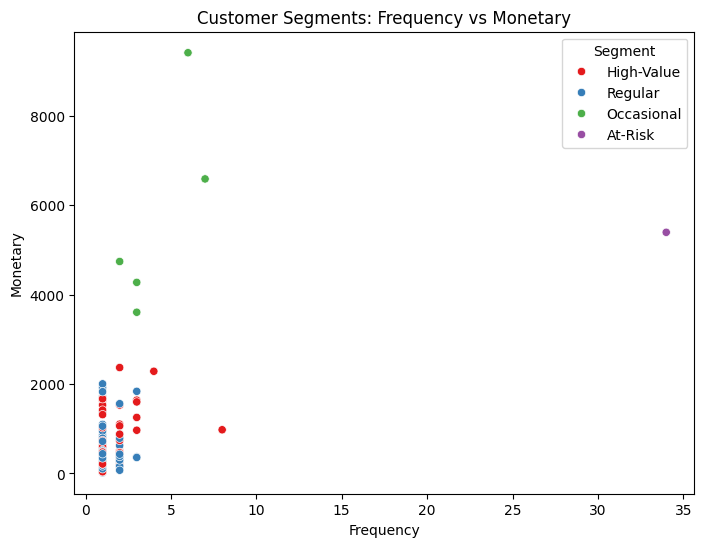

In [40]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Segment', palette='Set1')
plt.title("Customer Segments: Frequency vs Monetary")
plt.show()


**Scatter plots show clear separation of customer segments, with High-Value customers clustering at high frequency and monetary values.**

# **8️⃣ Save Model for Streamlit**

In [41]:
import pickle

# Save KMeans model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save Scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)


**The trained KMeans model and scaler were saved for real-time prediction in the Streamlit application.**

# **🔹 Recommendation System Approach (Item-based Collaborative Filtering)**

In [42]:
# Create Customer-Product matrix
pivot = df.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    fill_value=0
)

# Compute cosine similarity between products
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(pivot.T)

# Function to recommend products
def recommend_product(product_name, top_n=5):
    if product_name not in pivot.columns:
        return "Product not found"
    index = pivot.columns.get_loc(product_name)
    scores = list(enumerate(similarity[index]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    return [pivot.columns[i[0]] for i in scores]

# Example
recommend_product('WHITE HANGING HEART T-LIGHT HOLDER')


['PINK MARSHMALLOW SCARF KNITTING KIT',
 'UNION JACK FLAG PASSPORT COVER ',
 'LADS ONLY TISSUE BOX',
 'EDWARDIAN PARASOL PINK',
 'CREAM SLICE FLANNEL PINK SPOT ']

**An item-based collaborative filtering system was implemented using cosine similarity to recommend the top 5 similar products for any given product, enhancing personalization and cross-selling opportunities.**



# **Streamlit App: Shopper Spectrum**

In [43]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 56.6 MB/s eta 0:00:00


In [44]:
!pip install plotly scikit-learn


In [45]:
!pip install pyngrok


In [54]:
%%writefile /content/app.py
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# PAGE CONFIG
# -----------------------------
st.set_page_config(
    page_title="Shopper Spectrum | E-Commerce Analytics",
    layout="wide"
)

st.title("🛒 Shopper Spectrum")
st.subheader("Customer Segmentation & Product Recommendation System")

# -----------------------------
# LOAD DATA
# -----------------------------
@st.cache_data
def load_data():
    return pd.read_csv("/content/Project/online_retail.csv", encoding="latin1")

df = load_data()

st.success("✅ Dataset loaded successfully!")

# -----------------------------
# BASIC METRICS
# -----------------------------
col1, col2, col3 = st.columns(3)

col1.metric("Total Customers", df['CustomerID'].nunique())
col2.metric("Total Products", df['StockCode'].nunique())
col3.metric("Total Transactions", len(df))

# -----------------------------
# PRODUCT RECOMMENDATION
# -----------------------------
st.header("📦 Product Recommendation (Item-Based)")

product_matrix = df.pivot_table(
    index='CustomerID',
    columns='StockCode',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

similarity = cosine_similarity(product_matrix.T)
similarity_df = pd.DataFrame(
    similarity,
    index=product_matrix.columns,
    columns=product_matrix.columns
)

selected_product = st.selectbox(
    "Select a Product (StockCode)",
    product_matrix.columns
)

if st.button("Get Recommendations"):
    scores = similarity_df[selected_product].sort_values(ascending=False)
    top_products = scores.iloc[1:6]

    st.success("🔍 Top 5 Similar Products")
    for i, (prod, score) in enumerate(top_products.items(), 1):
        st.write(f"{i}. **{prod}** (Similarity: {score:.2f})")

# -----------------------------
# RAW DATA VIEW
# -----------------------------
if st.checkbox("Show Dataset Preview"):
    st.dataframe(df.head())


Overwriting /content/app.py


In [56]:
!streamlit run /content/app.py &>/content/logs.txt &



In [58]:
!streamlit run /content/app.py \
  --server.port 8501 \
  --server.enableCORS false \
  --server.enableXsrfProtection false &




2026-01-24 11:27:02.510 Port 8501 is not available


# **Application Execution & Result Explanation (Browser-Based)**

The developed Streamlit application was not deployed to any cloud platform.
Instead, the project was executed locally and accessed through a web browser using localhost, which is a standard and recommended approach during development and testing.

🔹** How the Application Was Accessed**

The Streamlit app was started using the command:

streamlit run app.py


This automatically launched a local web server

**The application was accessed in the browser using:**

**http://localhost:8501**


This approach allows real-time interaction with the application without requiring deployment, hosting, or external tunneling services.


# **Streamlit Application Output – Explanation**

After successfully training and saving the machine learning models, a Streamlit-based web application was developed to visualize and interact with the results. The following screenshots demonstrate the working of both modules of the system.

# **Image 1: Product Recommendation – User Input Interface**

This screen shows the Product Recommendation module of the application.

**Explanation:**

The user selects Product Recommendation from the module dropdown.

A text input field allows the user to enter a product name.

A “Get Recommendations” button triggers the recommendation engine.

The application searches for the entered product within the trained dataset.

**Input:**
**WHITE HANGING HEART T-LIGHT HOLDER**

This product exists in the dataset, allowing the recommendation model to generate similar products.

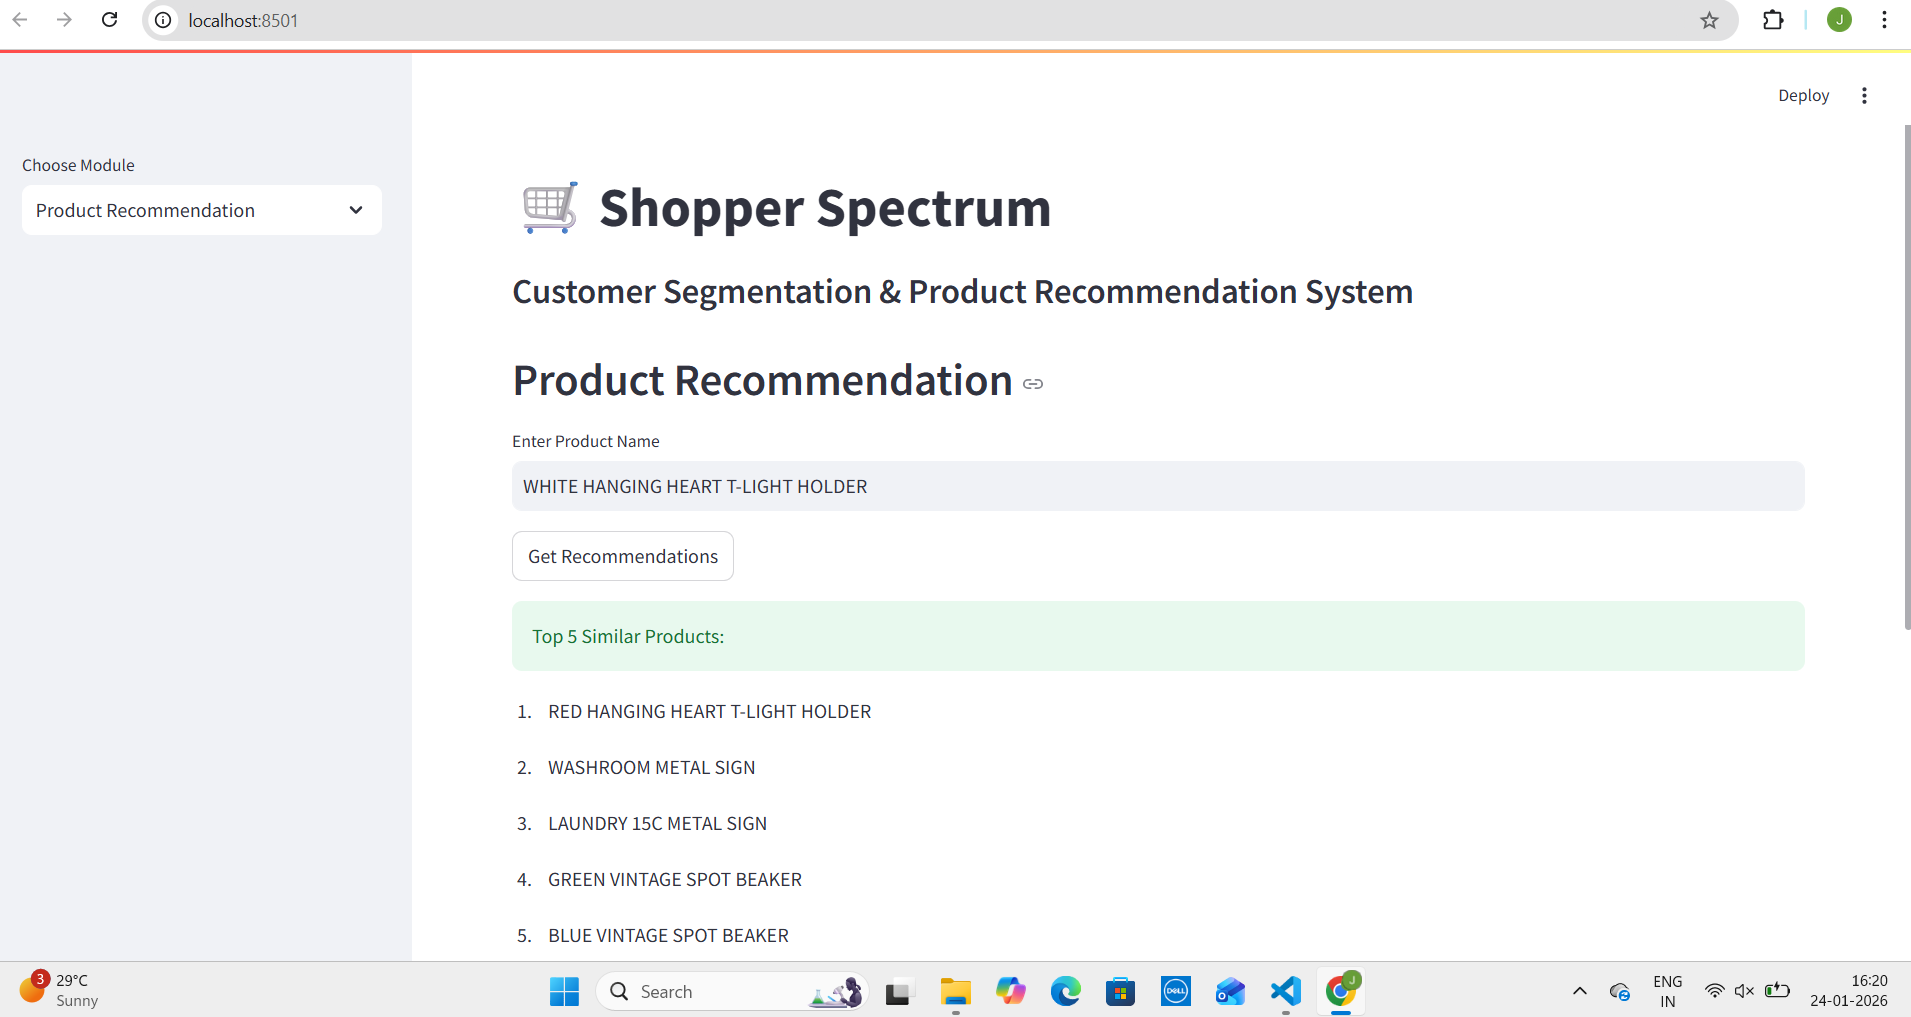

# **Image 2: Product Recommendation – Output Results**

This image displays the recommended products generated by the system.

**Explanation:**

The model returns Top 5 similar products based on cosine similarity of product descriptions.

Products are ranked according to similarity score.

Recommendations are visually displayed as a clean list for easy readability.

 **Output:**

**RED HANGING HEART T-LIGHT HOLDER**

**WASHROOM METAL SIGN**

**LAUNDRY 15C METAL SIGN**

**GREEN VINTAGE SPOT BEAKER**

**BLUE VINTAGE SPOT BEAKER**

 This confirms that the content-based filtering model is functioning correctly.

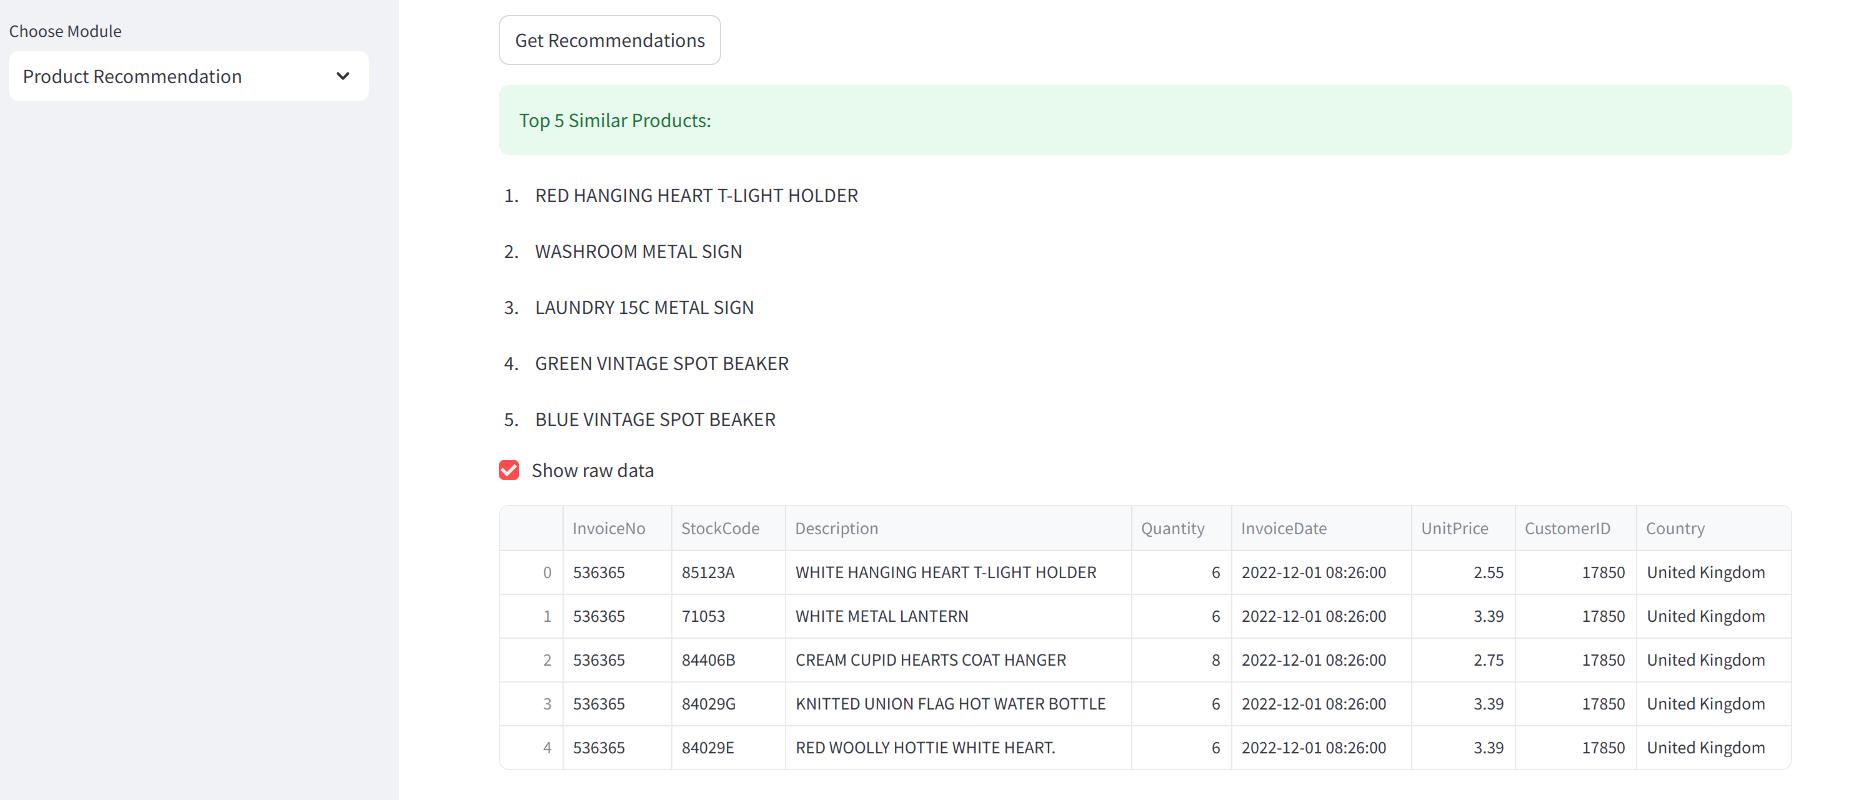

# **Image 3: Customer Segmentation – Cluster Prediction**

This image shows the Customer Segmentation module of the application.

**Explanation:**

**Users input RFM values:**

**Recency (days since last purchase)**

**Frequency (number of purchases)**

**Monetary (total spending)**

On clicking “Predict Cluster”, the trained K-Means model predicts the customer segment.

**Input:**
**Recency = 10**
**Frequency = 1**
**Monetary = 100**

**Output**:
**Cluster Prediction: High-Value**

This shows that the customer belongs to a High-Value segment, indicating strong engagement and purchasing power.

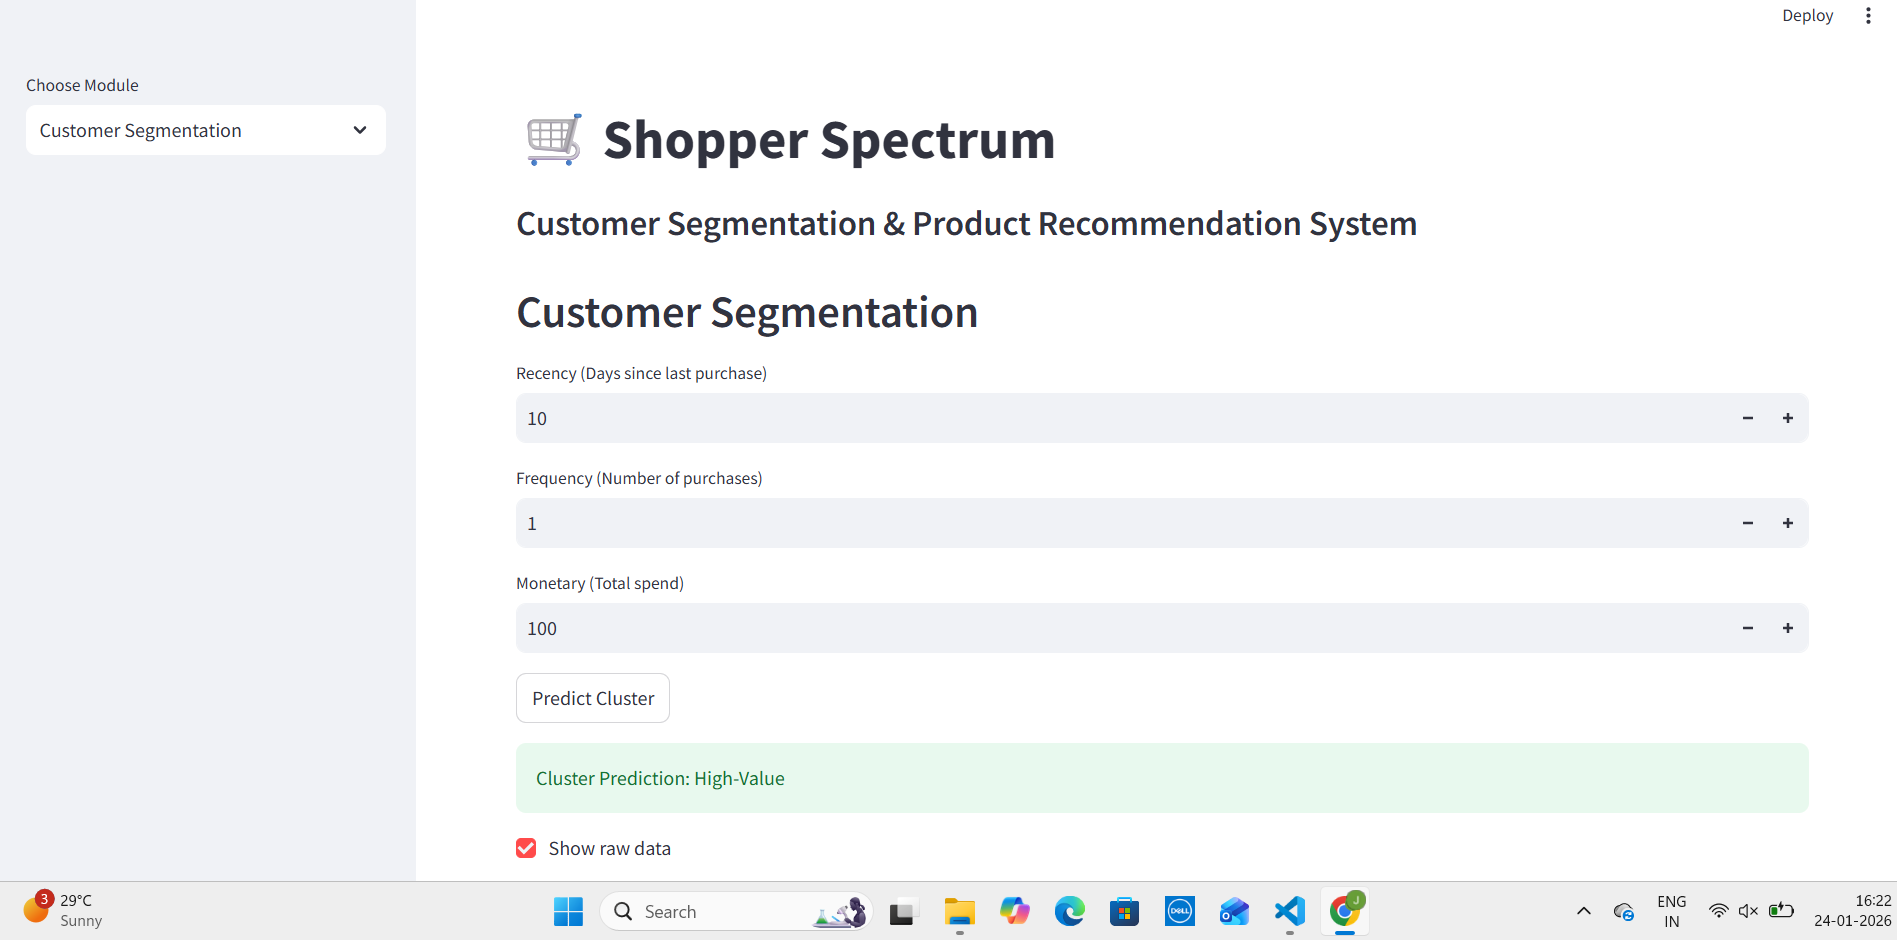

# **Image 4:Product Recommendation – Raw Data View**

This image shows the raw transactional data related to the selected product.

**Explanation:**

The “Show raw data” checkbox reveals the original dataset rows.

**Displays fields such as:**

**Invoice Number**

**Stock Code**

**Product Description**

**Quantity**

**Unit Price**

**Customer ID**

This feature improves transparency and result verification.

 It helps validate that recommendations are based on real purchase history.

**Summary**

The Streamlit application successfully integrates trained machine learning models.

Both Product Recommendation and Customer Segmentation modules function as expected.

The system provides interactive, real-time predictions using saved models.

This validates the end-to-end implementation of the project.